# Auditoría del target e intermitencia semanal
`cantidad` se interpreta como cantidad neta semanal en la escala registrada por el ERP, no automáticamente como unidades vendidas. No se combinan cantidad/unidades ni se inventan equivalencias de empaque. MAE y RMSE siguen en la escala original, sin normalización.

Los movimientos negativos son patrones compatibles con anulaciones, devoluciones o ajustes operativos; su causa individual no se conoce. Se conservan durante la suma semanal, y sólo el saldo neto semanal negativo se trunca a cero para modelado. `cantidad_neta_original` conserva evidencia operativa y `cantidad` es el target no negativo. NaN no significa cero. Los huecos interiores sin registros se rellenan bajo el supuesto de continuidad de captura.

In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing.demanda_semanal import (
    construir_semanal, resumir_intermitencia, excluir_semana_corte, auditar_target)

df = pd.read_csv('../datasets/dataset_maestro_dashboard.csv')
df['fecdoc'] = pd.to_datetime(df['fecdoc'], errors='raise')
salida = Path('../resultados/semanal')
salida.mkdir(parents=True, exist_ok=True)
auditoria = auditar_target(df)
auditoria.to_csv(salida / 'auditoria_target.csv', index=False)
display(auditoria)
negativos = df[df.cantidad.lt(0)].copy()
negativos.to_csv(salida / 'movimientos_negativos_originales.csv', index_label='indice_original')
print('Movimientos negativos:', len(negativos), '| suma:', negativos.cantidad.sum())
display(negativos.sort_values('fecdoc'))
display(negativos.groupby(['sucursal','producto']).cantidad.agg(['count','sum','min']))

semanal = construir_semanal(df)
evaluable, excluidas = excluir_semana_corte(semanal)
ajustes = semanal[semanal.cantidad_neta_original.lt(0)].copy()
ajustes = ajustes.rename(columns={'cantidad_neta_original':'valor_antes', 'cantidad':'valor_despues'})
ajustes.to_csv(salida / 'ajustes_negativos_semanales.csv', index=False)
display(ajustes)
resumen_auditoria = {
    'movimientos_negativos': len(negativos), 'suma_movimientos_negativos': float(negativos.cantidad.sum()),
    'semanas_netas_negativas': len(ajustes),
    'cantidad_cero_unidades_positivas': int((df.cantidad.eq(0) & df.unidades.gt(0)).sum()),
    'cantidad_positiva_unidades_positivas': int((df.cantidad.gt(0) & df.unidades.gt(0)).sum()),
    'observaciones_semanales_calendario': len(semanal), 'semanas_evaluables': len(evaluable),
    'observaciones_excluidas_corte': len(excluidas),
    'transacciones_semana_cruzada': int(df.fecdoc.between('2025-12-29','2026-01-04 23:59:59.999999999').sum())
}
(salida / 'resumen_auditoria_target.json').write_text(json.dumps(resumen_auditoria, indent=2), encoding='utf-8')
semanal.to_csv(salida / 'dataset_semanal.csv', index=False)
evaluable.to_csv(salida / 'dataset_semanal_evaluable.csv', index=False)
excluidas.to_csv(salida / 'semanas_excluidas_corte.csv', index=False)

,condicion,producto,registros,suma_cantidad,productos_afectados
0,cantidad_cero_unidades_positivas,__TOTAL__,40928,0.0,13
1,cantidad_cero_unidades_positivas,AMOXICILINA 500MG,1869,0.0,1
2,cantidad_cero_unidades_positivas,AZITROMICINA 500MG,3014,0.0,1
3,cantidad_cero_unidades_positivas,CETIRIZINA 10MG,7419,0.0,1
4,cantidad_cero_unidades_positivas,DIMENHIDRINATO 50MG,1546,0.0,1
5,cantidad_cero_unidades_positivas,ENALAPRIL 10MG,2152,0.0,1
6,cantidad_cero_unidades_positivas,IBUPROFENO TABX800,1645,0.0,1
7,cantidad_cero_unidades_positivas,LOPERAMIDA 2MG,568,0.0,1
8,cantidad_cero_unidades_positivas,LORATADINA 10MG,2163,0.0,1
9,cantidad_cero_unidades_positivas,LOSARTAN 50MG,1936,0.0,1


Movimientos negativos: 74 | suma: -93.0


,codpro,prod,tipo,cantidad,unidades,total,fecdoc,sucursal,mes,estacion,producto,categoria_abc
21101,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,-1.0,0.0,-20.00,2024-01-03 12:00:00,1,1,Verano,LOSARTAN 50MG,Clase B (Rotación Media)
36064,100923,PARACETAMOL 500MG CJAX100TAB,GENFAR,-1.0,0.0,-10.01,2024-01-06 12:00:00,4,1,Verano,PARACETAMOL 500MG,Clase B (Rotación Media)
21237,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,-1.0,0.0,-20.70,2024-01-27 12:00:00,10,1,Verano,LOSARTAN 50MG,Clase B (Rotación Media)
36699,100923,PARACETAMOL 500MG CJAX100TAB,GENFAR,-1.0,0.0,-10.00,2024-02-13 12:00:00,1,2,Verano,PARACETAMOL 500MG,Clase B (Rotación Media)
21316,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,-1.0,0.0,-20.70,2024-02-20 12:00:00,1,2,Verano,LOSARTAN 50MG,Clase B (Rotación Media)
...,...,...,...,...,...,...,...,...,...,...,...,...
23878,100018,METFORMINA 850MG TAB CJAX30UND,GENFAR,-1.0,0.0,-10.50,2026-04-25 20:21:08,16,4,Otoño,METFORMINA 850MG,Clase B (Rotación Media)
44291,107417,VITAMINA C+ZINC+D3 NARANJA TAB.EFERV. TBOX20UND,EUROCARE,-1.0,0.0,-14.50,2026-06-07 15:12:53,11,6,Invierno,VITAMINA C+ZINC+D3,Clase A (Alta Rotación)
16454,101410,ENALAPRIL 10MG TAB CJAX140UND,FARM.GENERICOS,-1.0,0.0,-9.00,2026-06-09 19:53:02,10,6,Invierno,ENALAPRIL 10MG,Clase A (Alta Rotación)
44324,107417,VITAMINA C+ZINC+D3 NARANJA TAB.EFERV. TBOX20UND,EUROCARE,-1.0,0.0,-15.12,2026-06-29 11:05:18,1,6,Invierno,VITAMINA C+ZINC+D3,Clase A (Alta Rotación)


count   sum   min
sucursal producto                              
1        AZITROMICINA 500MG       1  -1.0  -1.0
         ENALAPRIL 10MG           2  -2.0  -1.0
         LOSARTAN 50MG            3  -4.0  -2.0
         PARACETAMOL 500MG        1  -1.0  -1.0
         VITAMINA C+ZINC+D3       3  -3.0  -1.0
2        AMOXICILINA 500MG        2  -3.0  -2.0
         CETIRIZINA 10MG          1  -1.0  -1.0
         ENALAPRIL 10MG           1  -1.0  -1.0
         METFORMINA 850MG         1  -1.0  -1.0
         NAPROXENO TABX550MG      2  -3.0  -2.0
         PARACETAMOL 500MG        1  -1.0  -1.0
         VITAMINA C+ZINC+D3       4  -6.0  -2.0
3        AMOXICILINA 500MG        1 -10.0 -10.0
         DIMENHIDRINATO 50MG      1  -1.0  -1.0
         VITAMINA C+ZINC+D3       2  -2.0  -1.0
4        ENALAPRIL 10MG           1  -1.0  -1.0
         PARACETAMOL 500MG        1  -1.0  -1.0
         VITAMINA C+ZINC+D3       3  -4.0  -2.0
5        LOSARTAN 50MG            1  -1.0  -1.0
         METFORMINA 850MG         1  -2.0  -2.0
         NAPROXENO TABX550MG      1  -1.0  -1.0
         VITAMINA C+ZINC+D3       3  -4.0  -2.0
6        METFORMINA 850MG         1  -1.0  -1.0
         VITAMINA C+ZINC+D3       1  -1.0  -1.0
7        METFORMINA 850MG         1  -1.0  -1.0
9        AMOXICILINA 500MG        1  -1.0  -1.0
         CETIRIZINA 10MG          1  -1.0  -1.0
         METFORMINA 850MG         2  -3.0  -2.0
         VITAMINA C+ZINC+D3       1  -1.0  -1.0
10       ENALAPRIL 10MG           2  -2.0  -1.0
         LOSARTAN 50MG            2  -2.0  -1.0
         NAPROXENO TABX550MG      1  -1.0  -1.0
         VITAMINA C+ZINC+D3       5  -5.0  -1.0
11       VITAMINA C+ZINC+D3       4  -4.0  -1.0
12       AZITROMICINA 500MG       1  -2.0  -2.0
         ENALAPRIL 10MG           1  -1.0  -1.0
         LOSARTAN 50MG            1  -1.0  -1.0
         NAPROXENO TABX550MG      1  -1.0  -1.0
         VITAMINA C+ZINC+D3       3  -3.0  -1.0
15       ENALAPRIL 10MG           1  -1.0  -1.0
         LOSARTAN 50MG            1  -1.0  -1.0
         VITAMINA C+ZINC+D3       2  -2.0  -1.0
16       METFORMINA 850MG         1  -1.0  -1.0
         VITAMINA C+ZINC+D3       3  -3.0  -1.0

,sucursal,producto,semana,valor_antes,valor_despues
3012,3,AMOXICILINA 500MG,2025-11-02,-10.0,0.0
3347,3,DIMENHIDRINATO 50MG,2025-11-02,-1.0,0.0


## Ejemplos operativos, sin atribuir causas no verificadas
Se muestra para cada negativo su contexto de transacciones en la misma sucursal-producto y día. Una coincidencia de importes o cantidades opuestas es compatible con corrección/anulación, pero no acredita su causa sin documentación ERP. El archivo de contextos incluye todos los casos, no sólo los ejemplos mostrados.

In [2]:
claves_negativas = negativos[['sucursal','producto']].copy()
claves_negativas['dia'] = negativos.fecdoc.dt.normalize()
contexto = df.assign(dia=df.fecdoc.dt.normalize()).merge(
    claves_negativas.drop_duplicates(), on=['sucursal','producto','dia'], how='inner')
contexto = contexto.sort_values(['sucursal','producto','fecdoc'])
contexto.to_csv(salida / 'contexto_movimientos_negativos.csv', index=False)
for clave, grupo in list(contexto.groupby(['sucursal','producto','dia']))[:5]:
    print('Contexto operativo:', clave)
    display(grupo)

Contexto operativo: (1, 'AZITROMICINA 500MG', Timestamp('2025-04-09 00:00:00'))


,codpro,prod,tipo,cantidad,unidades,total,fecdoc,sucursal,mes,estacion,producto,categoria_abc,dia
13,101069,AZITROMICINA 500MG TAB CJAX30UNID.,ACFARMA GENERICO,0.0,4.0,4.0,2025-04-09 09:54:00,1,4,Otoño,AZITROMICINA 500MG,Clase C (Baja Rotación),2025-04-09
14,101069,AZITROMICINA 500MG TAB CJAX30UNID.,ACFARMA GENERICO,1.0,0.0,30.0,2025-04-09 11:05:31,1,4,Otoño,AZITROMICINA 500MG,Clase C (Baja Rotación),2025-04-09
15,101069,AZITROMICINA 500MG TAB CJAX30UNID.,ACFARMA GENERICO,-1.0,0.0,-30.0,2025-04-09 11:13:00,1,4,Otoño,AZITROMICINA 500MG,Clase C (Baja Rotación),2025-04-09
16,101069,AZITROMICINA 500MG TAB CJAX30UNID.,ACFARMA GENERICO,0.0,10.0,10.0,2025-04-09 11:14:12,1,4,Otoño,AZITROMICINA 500MG,Clase C (Baja Rotación),2025-04-09
17,101069,AZITROMICINA 500MG TAB CJAX30UNID.,ACFARMA GENERICO,0.0,2.0,2.0,2025-04-09 19:38:30,1,4,Otoño,AZITROMICINA 500MG,Clase C (Baja Rotación),2025-04-09


Contexto operativo: (1, 'ENALAPRIL 10MG', Timestamp('2025-10-30 00:00:00'))


,codpro,prod,tipo,cantidad,unidades,total,fecdoc,sucursal,mes,estacion,producto,categoria_abc,dia
37,101410,ENALAPRIL 10MG TAB CJAX140UND,FARM.GENERICOS,1.0,0.0,9.5,2025-10-30 18:14:18,1,10,Primavera,ENALAPRIL 10MG,Clase A (Alta Rotación),2025-10-30
38,101410,ENALAPRIL 10MG TAB CJAX140UND,FARM.GENERICOS,-1.0,0.0,-9.5,2025-10-30 18:22:31,1,10,Primavera,ENALAPRIL 10MG,Clase A (Alta Rotación),2025-10-30
39,101410,ENALAPRIL 10MG TAB CJAX140UND,FARM.GENERICOS,-1.0,0.0,-9.5,2025-10-30 18:23:11,1,10,Primavera,ENALAPRIL 10MG,Clase A (Alta Rotación),2025-10-30


Contexto operativo: (1, 'LOSARTAN 50MG', Timestamp('2024-01-03 00:00:00'))


,codpro,prod,tipo,cantidad,unidades,total,fecdoc,sucursal,mes,estacion,producto,categoria_abc,dia
52,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,-1.0,0.0,-20.0,2024-01-03 12:00:00,1,1,Verano,LOSARTAN 50MG,Clase B (Rotación Media),2024-01-03
53,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,1.0,0.0,20.0,2024-01-03 16:50:14,1,1,Verano,LOSARTAN 50MG,Clase B (Rotación Media),2024-01-03
54,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,1.0,0.0,20.0,2024-01-03 16:54:13,1,1,Verano,LOSARTAN 50MG,Clase B (Rotación Media),2024-01-03


Contexto operativo: (1, 'LOSARTAN 50MG', Timestamp('2024-02-20 00:00:00'))


,codpro,prod,tipo,cantidad,unidades,total,fecdoc,sucursal,mes,estacion,producto,categoria_abc,dia
60,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,1.0,0.0,20.7,2024-02-20 08:51:16,1,2,Verano,LOSARTAN 50MG,Clase B (Rotación Media),2024-02-20
61,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,-1.0,0.0,-20.7,2024-02-20 12:00:00,1,2,Verano,LOSARTAN 50MG,Clase B (Rotación Media),2024-02-20


Contexto operativo: (1, 'LOSARTAN 50MG', Timestamp('2025-09-16 00:00:00'))


,codpro,prod,tipo,cantidad,unidades,total,fecdoc,sucursal,mes,estacion,producto,categoria_abc,dia
72,102721,LOSARTAN 50MG COM. REC CJAX100UND,PERUFARMA GENERICO,0.0,30.0,6.0,2025-09-16 17:19:32,1,9,Primavera,LOSARTAN 50MG,Clase B (Rotación Media),2025-09-16
73,102721,LOSARTAN 50MG COM. REC CJAX100UND,PERUFARMA GENERICO,2.0,0.0,39.2,2025-09-16 18:20:33,1,9,Primavera,LOSARTAN 50MG,Clase B (Rotación Media),2025-09-16
74,102721,LOSARTAN 50MG COM. REC CJAX100UND,PERUFARMA GENERICO,2.0,0.0,39.2,2025-09-16 18:23:48,1,9,Primavera,LOSARTAN 50MG,Clase B (Rotación Media),2025-09-16
75,102721,LOSARTAN 50MG COM. REC CJAX100UND,PERUFARMA GENERICO,-2.0,0.0,-39.2,2025-09-16 18:26:38,1,9,Primavera,LOSARTAN 50MG,Clase B (Rotación Media),2025-09-16


## Registro original versus target de modelado
Se presentan tanto las 240 combinaciones observadas en el calendario completo como el universo evaluable tras excluir la semana de cruce del corte. El EDA no elimina series por intermitencia o por falta de lags. Las métricas de intermitencia no implican que cajas cero sea ausencia de ventas en unidades. La semana cruzada permanece en la evidencia original.

,universo,variable,observaciones,porcentaje_ceros,valores_positivos,saldos_negativos,media,mediana,min,max,combinaciones
0,calendario_completo,cantidad_neta_original,21123,90.455901,2014,2,0.149884,0.0,-10.0,14.0,240
1,calendario_completo,cantidad,21123,90.465370,2014,0,0.150405,0.0,0.0,14.0,240
2,evaluable_sin_cruce,cantidad_neta_original,20979,90.438057,2004,2,0.150245,0.0,-10.0,14.0,240
3,evaluable_sin_cruce,cantidad,20979,90.447590,2004,0,0.150770,0.0,0.0,14.0,240


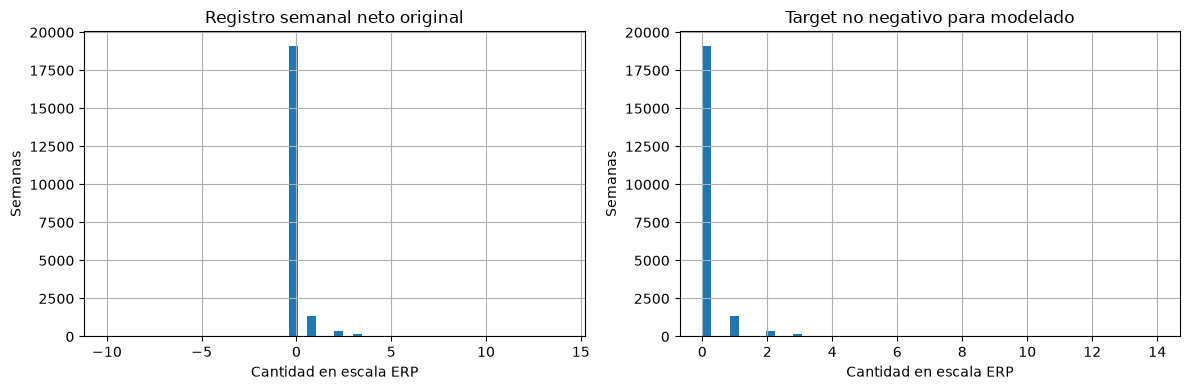

Potenciales: 266 | observadas: 240


,sucursal,producto,semanas_totales,semanas_demanda_cero,porcentaje_demanda_cero,demanda_promedio_semanal,inicio,fin
5,1,IBUPROFENO TABX800,132,132,100.000000,0.000000,2024-01-07,2026-07-19
34,3,LOPERAMIDA 2MG,130,130,100.000000,0.000000,2024-01-21,2026-07-19
39,3,OMEPRAZOL 20MG,27,27,100.000000,0.000000,2024-09-15,2025-03-16
43,4,AZITROMICINA 500MG,134,134,100.000000,0.000000,2024-01-07,2026-08-02
47,4,IBUPROFENO TABX800,132,132,100.000000,0.000000,2024-01-07,2026-07-19
29,3,AZITROMICINA 500MG,126,126,100.000000,0.000000,2024-01-07,2026-06-07
20,2,LOPERAMIDA 2MG,27,27,100.000000,0.000000,2026-01-25,2026-07-26
17,2,DIMENHIDRINATO 50MG,130,130,100.000000,0.000000,2024-02-04,2026-08-02
35,3,LORATADINA 10MG,106,106,100.000000,0.000000,2024-01-07,2026-01-18
75,6,LOPERAMIDA 2MG,132,132,100.000000,0.000000,2024-01-21,2026-08-02


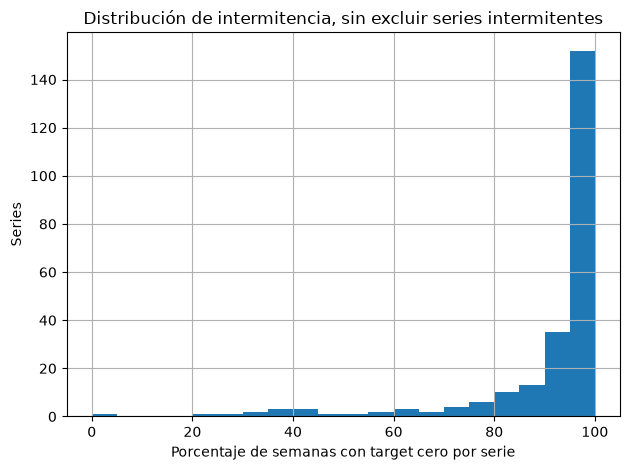

In [4]:
estadisticas = []
for universo, marco in [('calendario_completo', semanal), ('evaluable_sin_cruce', evaluable)]:
    for variable in ['cantidad_neta_original','cantidad']:
        v = marco[variable]
        estadisticas.append({'universo':universo, 'variable':variable, 'observaciones':len(v),
            'porcentaje_ceros':v.eq(0).mean()*100, 'valores_positivos':int(v.gt(0).sum()),
            'saldos_negativos':int(v.lt(0).sum()), 'media':v.mean(), 'mediana':v.median(),
            'min':v.min(), 'max':v.max(), 'combinaciones':marco.groupby(['sucursal','producto']).ngroups})
resumen_distribucion = pd.DataFrame(estadisticas)
display(resumen_distribucion)
resumen_distribucion.to_csv(salida / 'distribucion_target.csv', index=False)
fig, axes = plt.subplots(1,2,figsize=(12,4))
semanal.cantidad_neta_original.hist(bins=50, ax=axes[0])
semanal.cantidad.hist(bins=50, ax=axes[1])
axes[0].set_title('Registro semanal neto original')
axes[1].set_title('Target no negativo para modelado')
for ax in axes:
    ax.set_xlabel('Cantidad en escala ERP'); ax.set_ylabel('Semanas')
plt.tight_layout(); plt.show()

intermitencia_original = resumir_intermitencia(semanal, target='cantidad_neta_original')
intermitencia_original.to_csv(salida / 'intermitencia_original.csv', index=False)
resumir_intermitencia(semanal).to_csv(salida / 'intermitencia_semanal_completa.csv', index=False)
df_intermitencia = resumir_intermitencia(evaluable)
df_intermitencia.to_csv(salida / 'intermitencia_semanal.csv', index=False)
print('Potenciales:', df.sucursal.nunique()*df.producto.nunique(), '| observadas:', len(intermitencia_original))
with pd.option_context('display.max_rows', None):
    display(df_intermitencia.sort_values('porcentaje_demanda_cero', ascending=False))
df_intermitencia.porcentaje_demanda_cero.hist(bins=20)
plt.xlabel('Porcentaje de semanas con target cero por serie'); plt.ylabel('Series')
plt.title('Distribución de intermitencia, sin excluir series intermitentes')
plt.tight_layout(); plt.show()

ENALAPRIL 10MG | sucursales: 19


,sucursal,producto,semanas_totales,semanas_demanda_cero,porcentaje_demanda_cero,demanda_promedio_semanal,inicio,fin
4,1,ENALAPRIL 10MG,133,94,70.676692,0.360902,2024-01-07,2026-07-26
18,2,ENALAPRIL 10MG,133,101,75.939850,0.270677,2024-01-07,2026-07-26
32,3,ENALAPRIL 10MG,132,108,81.818182,0.212121,2024-01-21,2026-08-02
46,4,ENALAPRIL 10MG,132,112,84.848485,0.166667,2024-01-14,2026-07-26
59,5,ENALAPRIL 10MG,130,98,75.384615,0.276923,2024-01-28,2026-07-26
73,6,ENALAPRIL 10MG,134,119,88.805970,0.268657,2024-01-07,2026-08-02
87,7,ENALAPRIL 10MG,133,119,89.473684,0.105263,2024-01-07,2026-07-26
100,8,ENALAPRIL 10MG,132,126,95.454545,0.045455,2024-01-07,2026-07-19
114,9,ENALAPRIL 10MG,133,117,87.969925,0.120301,2024-01-07,2026-07-26
128,10,ENALAPRIL 10MG,133,94,70.676692,0.315789,2024-01-07,2026-07-26


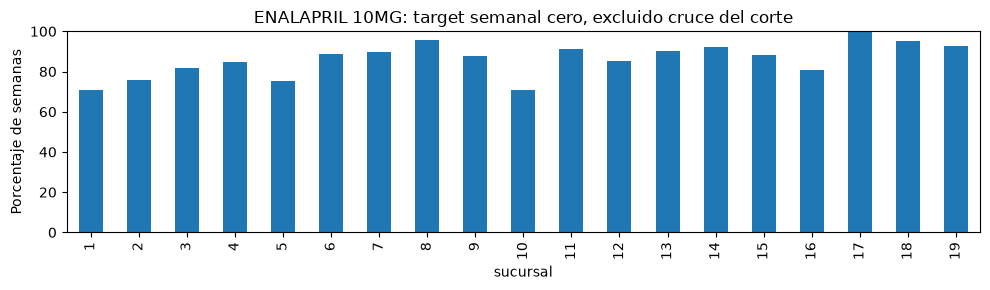

METFORMINA 850MG | sucursales: 19


,sucursal,producto,semanas_totales,semanas_demanda_cero,porcentaje_demanda_cero,demanda_promedio_semanal,inicio,fin
9,1,METFORMINA 850MG,124,99,79.838710,0.274194,2024-01-28,2026-06-14
23,2,METFORMINA 850MG,129,109,84.496124,0.193798,2024-01-07,2026-06-28
37,3,METFORMINA 850MG,127,114,89.763780,0.307087,2024-01-14,2026-06-21
51,4,METFORMINA 850MG,124,112,90.322581,0.112903,2024-03-17,2026-08-02
64,5,METFORMINA 850MG,129,105,81.395349,0.248062,2024-01-21,2026-07-12
78,6,METFORMINA 850MG,133,112,84.210526,0.195489,2024-01-07,2026-07-26
92,7,METFORMINA 850MG,134,128,95.522388,0.044776,2024-01-07,2026-08-02
105,8,METFORMINA 850MG,134,128,95.522388,0.052239,2024-01-07,2026-08-02
119,9,METFORMINA 850MG,131,121,92.366412,0.114504,2024-01-28,2026-08-02
133,10,METFORMINA 850MG,109,99,90.825688,0.110092,2024-01-14,2026-02-15


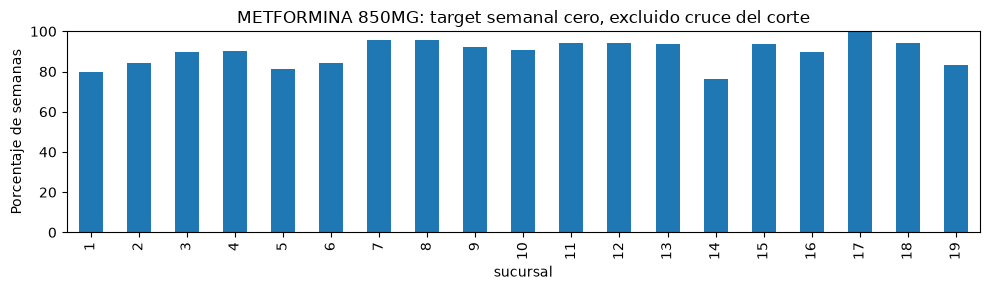

LOSARTAN 50MG | sucursales: 16


,sucursal,producto,semanas_totales,semanas_demanda_cero,porcentaje_demanda_cero,demanda_promedio_semanal,inicio,fin
8,1,LOSARTAN 50MG,97,60,61.855670,0.597938,2024-01-07,2025-11-09
22,2,LOSARTAN 50MG,97,80,82.474227,0.206186,2024-01-07,2025-11-09
36,3,LOSARTAN 50MG,107,87,81.308411,0.224299,2024-01-07,2026-01-25
50,4,LOSARTAN 50MG,96,69,71.875000,0.375000,2024-01-07,2025-11-02
63,5,LOSARTAN 50MG,95,65,68.421053,0.421053,2024-01-07,2025-10-26
77,6,LOSARTAN 50MG,97,86,88.659794,0.134021,2024-01-07,2025-11-09
91,7,LOSARTAN 50MG,97,87,89.690722,0.103093,2024-01-07,2025-11-09
104,8,LOSARTAN 50MG,95,87,91.578947,0.094737,2024-01-07,2025-10-26
118,9,LOSARTAN 50MG,96,80,83.333333,0.166667,2024-01-07,2025-11-02
132,10,LOSARTAN 50MG,97,83,85.567010,0.154639,2024-01-07,2025-11-09


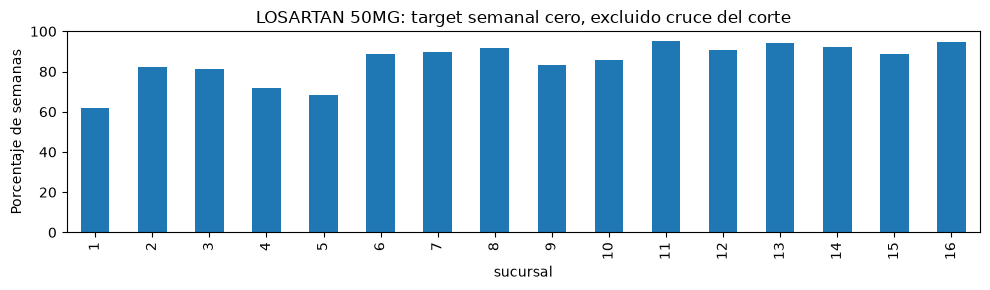

In [5]:
for producto in ['ENALAPRIL 10MG','METFORMINA 850MG','LOSARTAN 50MG']:
    caso = df_intermitencia[df_intermitencia.producto.str.upper().eq(producto)].sort_values('sucursal')
    print(producto, '| sucursales:', len(caso))
    display(caso)
    if not caso.empty:
        caso.plot.bar(x='sucursal', y='porcentaje_demanda_cero', legend=False, figsize=(10,3))
        plt.title(producto + ': target semanal cero, excluido cruce del corte')
        plt.ylim(0,100); plt.ylabel('Porcentaje de semanas'); plt.tight_layout(); plt.show()